# Termination Probability

> Summarize when participants stop recalling.

The termination probability curve summarizes when participants stop recalling. Two modes are available: *simple* mode reports the raw proportion of trials that terminate at each output position, while *conditional* mode divides by how many trials reached that position, giving a stopping hazard rate.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.termination_probability import plot_termination_probability
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
mode = "conditional"
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

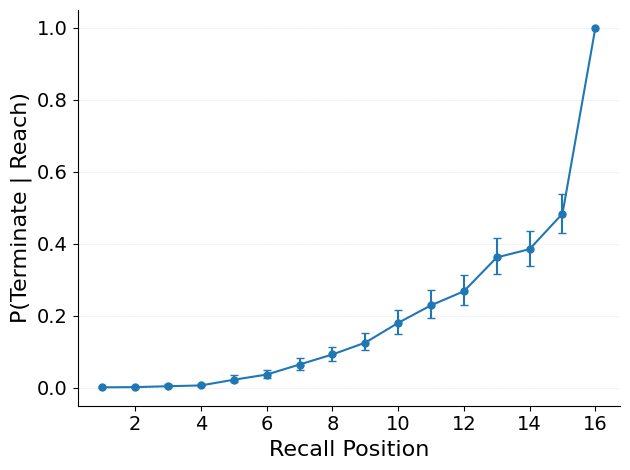

In [4]:
plot_termination_probability(datasets=data, trial_masks=trial_mask, mode=mode, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows output position and the y-axis shows the probability of stopping at that position. Key patterns:

- **Conditional mode**: a rising hazard rate indicates increasing difficulty of retrieval as the recall sequence progresses.
- **Simple mode**: the raw distribution of stopping points, which often peaks at early output positions.
- **Comparison**: conditional mode is generally more informative because it accounts for how many trials are still active at each position.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `mode` — `"conditional"` for hazard rate or `"simple"` for raw termination proportion.
- `confidence_level` — confidence level for subject-wise error bars.
